In [1]:
# Standard library
import json
import random
import time
from argparse import ArgumentParser

# Third-party
# for logging the model:
import pytorch_lightning as pl
import torch
from lightning_fabric.utilities import seed
from loguru import logger

# Local
from neural_lam import utils
from neural_lam.config import load_config_and_datastore
from neural_lam.models import EDM, GraphCast, GraphEFM, GraphFM, FM
from neural_lam.weather_dataset import WeatherDataModule

In [2]:
# Define args class
class Args:
    """Container for all arguments with default values."""
    
    def __init__(self):
        # Basic settings
        self.config_path = "/proj/berzelius-2022-164/weather/neural_lam_datasets/baltic/small_data/baltic_nl_config_tiny.yaml"
        self.model = "FM"
        self.seed = 42
        self.num_workers = 4
        self.num_nodes = 1
        self.devices = ["auto"]
        self.epochs = 200
        self.batch_size = 1
        self.load = None
        self.restore_opt = False
        self.precision = 32
        
        # Model architecture
        self.graph = "hierarchical"
        self.hidden_dim = 128
        self.latent_dim = None
        self.hidden_layers = 1
        self.processor_layers = 3
        self.encoder_processor_layers = 1
        self.prior_processor_layers = 1
        self.mesh_aggr = "sum"
        self.output_std = False
        self.prior_dist = "isotropic"
        self.learn_prior = 1
        self.vertical_propnets = 1
        
        # EDM options
        self.sigma_min = 0.002
        self.sigma_max = 88
        self.sigma_data = 1
        self.rho = 7
        self.sampler = "heun"
        self.sampler_steps = 20
        self.diffusion_model = "graph_diff"
        self.pred_residual = True
        
        # Training options
        self.ar_steps_train = 1
        self.loss = "wmse"
        self.lr = 1e-3
        self.val_interval = 1
        self.kl_beta = 1.0
        self.crps_weight = 0
        self.sample_obs_noise = 0
        self.num_sanity_val_steps = 4
        
        # Evaluation options
        self.eval = None
        self.ar_steps_eval = 1
        self.n_example_pred = 1
        self.num_latents_plot = 4
        
        # Logger Settings
        self.logger = "wandb"
        self.logger_project = "baltic-sea-forecasting"
        self.val_steps_to_log = [1, 2, 3]
        self.metrics_watch = []
        self.var_leads_metrics_watch = "{}"
        self.var_leads_val_plot = "{}"
        self.num_past_forcing_steps = 1
        self.num_future_forcing_steps = 1
        self.ensemble_size = 5

# Create the args object with all default values
args = Args()


In [3]:
# Initialize dataset

# Load neural-lam configuration and datastore to use
config, datastore = load_config_and_datastore(config_path=args.config_path)

# Create datamodule
data_module = WeatherDataModule(
    datastore=datastore,
    ar_steps_train=args.ar_steps_train,
    ar_steps_eval=args.ar_steps_eval,
    standardize=True,
    num_past_forcing_steps=args.num_past_forcing_steps,
    num_future_forcing_steps=args.num_future_forcing_steps,
    batch_size=args.batch_size,
    num_workers=args.num_workers,
)

# Important: Call these methods first to prepare and set up the datasets
data_module.prepare_data()
data_module.setup()

# Get 1 sample
# Get the train dataloader
train_dataloader = data_module.train_dataloader()
num_samples = len(train_dataloader)
print(f"The train dataloader contains {num_samples} batches")
# Get a single batch
batch = next(iter(train_dataloader))

init_states, target_states, forcing_features, time = batch

The loaded datastore contains the following features:
 state   : mlotst siconc sithick sla thetao0.5016462206840515 thetao10.809036254882812 thetao31.855070114135742 thetao103.82470703125 mwp swh
 forcing : msl t2m u10 v10 doy_sin doy_cos
 static  : deptho mdt
 mask    : mlotst siconc sithick sla mwp swh thetao0.5016462206840515 thetao10.809036254882812 thetao31.855070114135742 thetao103.82470703125
With the following splits (over time):
 train   : 2010-01-01T00:00 to 2010-01-10T00:00
 val     : 2010-01-10T00:00 to 2010-01-15T00:00
 test    : 2010-01-15T00:00 to 2010-01-20T00:00
The train dataloader contains 6 batches


In [4]:
# Experiment with a trained EDM model
from neural_lam.models import EDM, FM
import torch

if args.model == "EDM":
    # Create the model instance
    model = EDM(args, config=config, datastore=datastore)

    # Load the weights from checkpoint
    # checkpoint_path = "/proj/berzelius-2022-164/weather/neural_lam_datasets/baltic/10y-data/last.ckpt" # Old checkpoint
    # checkpoint_path = "/proj/berzelius-2022-164/weather/neural_lam_datasets/baltic/small_data/saved_models/train-EDM-2x64-09_10_10-5649/last.ckpt" # Latest Model
    # Tiny dataset
    checkpoint_path = "/proj/berzelius-2022-164/users/x_erila/baltic-sea-forecasting/saved_models/train-EDM-3x128-09_26_08-3548/last.ckpt" # EDM Overfit Tiny
elif args.model == "FM":
    model = FM(args, config=config, datastore=datastore)
    # checkpoint_path = "/proj/berzelius-2022-164/users/x_erila/baltic-sea-forecasting/saved_models/train-FM-3x128-09_19_13-7342/last.ckpt" # FM Overfit
    checkpoint_path = "/proj/berzelius-2022-164/users/x_erila/baltic-sea-forecasting/saved_models/train-FM-3x128-09_26_08-1149/last.ckpt" # FM Overfit tiny
# model = FM(args, config=config, datastore=datastore)
# checkpoint_path = "/proj/berzelius-2022-164/users/x_erila/baltic-sea-forecasting/saved_models/train-FM-3x128-09_26_08-1149/last.ckpt" # FM Overfit tiny
# Set weights_only=False to allow loading all types of objects
state_dict = torch.load(checkpoint_path, map_location="cpu", weights_only=False)["state_dict"]

# Remove 'model.' prefix if present in keys
if all(k.startswith('model.') for k in state_dict.keys()):
    state_dict = {k[6:]: v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=False)

# Move model to available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set model to evaluation mode
model.eval()

print(f"Successfully loaded model from {checkpoint_path}")

Using GraphDiff
Loaded graph with 164210 nodes (147087 grid, 17123 mesh)
Loaded hierarchical graph with structure:
level 0 - 15244 nodes, 113931 same-level edges
  0<->1
 - 15244 up edges, 15244 down edges
level 1 - 1696 nodes, 11830 same-level edges
  1<->2
 - 1696 up edges, 1696 down edges
level 2 - 183 nodes, 1042 same-level edges
Successfully loaded model from /proj/berzelius-2022-164/users/x_erila/baltic-sea-forecasting/saved_models/train-FM-3x128-09_26_08-1149/last.ckpt


In [5]:
target_state = target_states[:, 0]  # (B, N, F)
prev_prev_state = init_states[:, 0]
prev_state = init_states[:, 1]
forcing = forcing_features[:, 0]  # (B, N_grid, F_forcing)

if args.pred_residual:
    target = target_state - prev_state
else:
    target = (target_state - model.diff_mean) / model.diff_std 


feature_idx = 0  # Choose which weather variable to plot (e.g., temperature)

# Define range for the visualization
vrange = (target[:, feature_idx].min(), target[:, feature_idx].max())

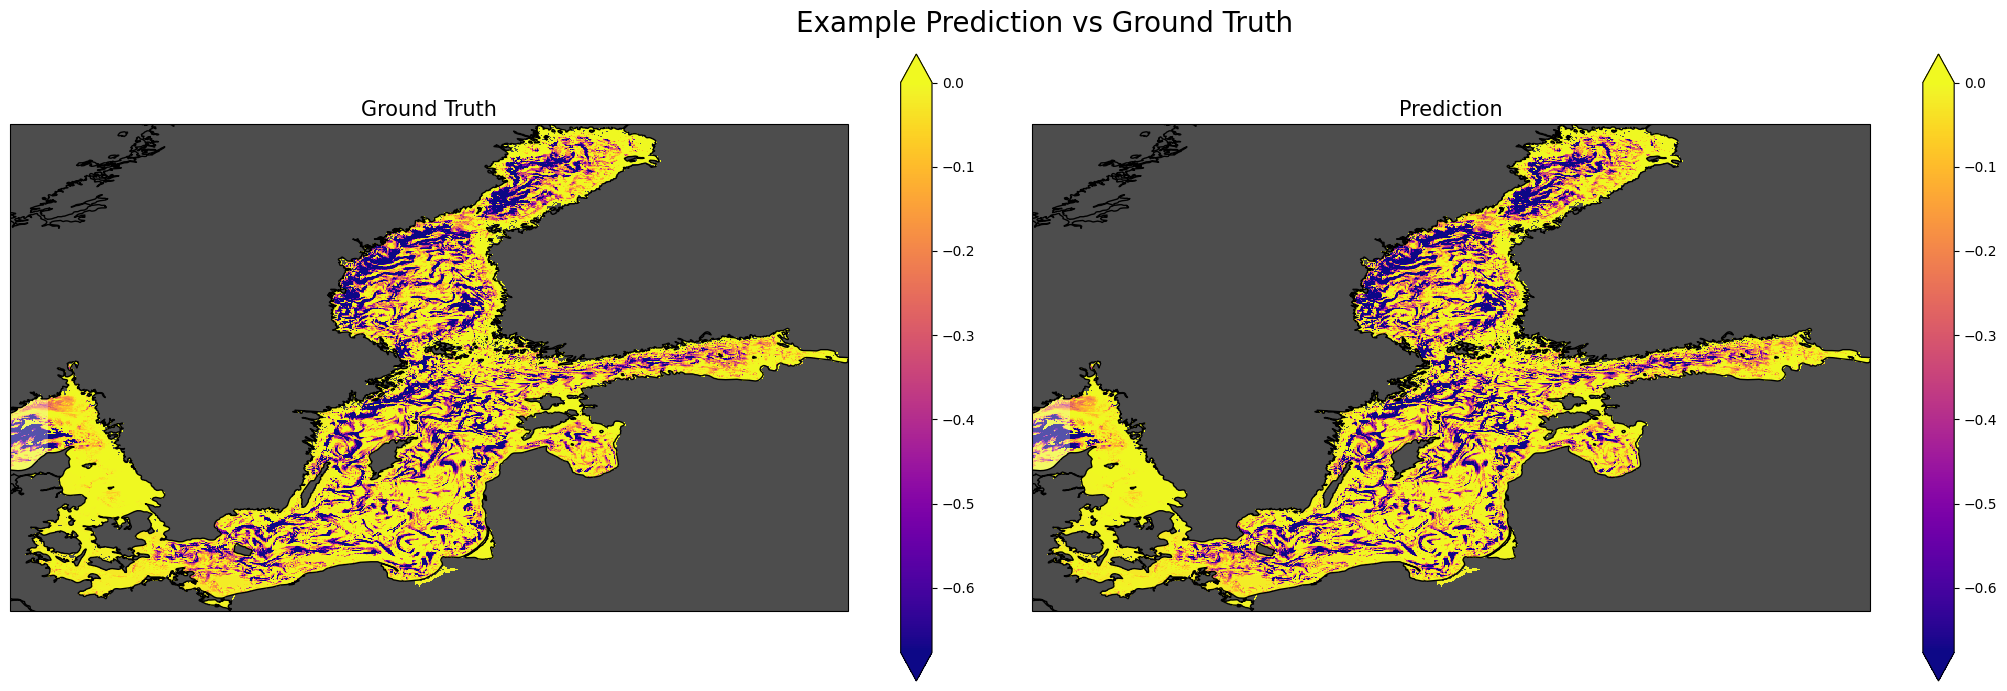

In [6]:
# Plotting function
from neural_lam.weather_dataset import WeatherDataset
from typing import List, Union
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from neural_lam.datastore.base import BaseRegularGridDatastore

split = "train"
target_slice = target  # (T, N, F)
time_slice = time[0, :]  # (T,)


def create_dataarray_from_tensor(
    tensor: torch.Tensor,
    time: Union[int, List[int]],
    split: str,
    category: str,
) -> xr.DataArray:
    """
    Create an `xr.DataArray` from a tensor, with the correct dimensions and
    coordinates to match the datastore used by the model. This function in
    in effect is the inverse of what is returned by
    `WeatherDataset.__getitem__`.

    Parameters
    ----------
    tensor : torch.Tensor
        The tensor to convert to a `xr.DataArray` with dimensions [time,
        grid_index, feature]. The tensor will be copied to the CPU if it is
        not already there.
    time : Union[int,List[int]]
        The time index or indices for the data, given as integers or a list
        of integers representing epoch time in nanoseconds. The ints will be
        copied to the CPU memory if they are not already there.
    split : str
        The split of the data, either 'train', 'val', or 'test'
    category : str
        The category of the data, either 'state' or 'forcing'
    """
    # TODO: creating an instance of WeatherDataset here on every call is
    # not how this should be done but whether WeatherDataset should be
    # provided to ARModel or where to put plotting still needs discussion
    weather_dataset = WeatherDataset(datastore=datastore, split=split)
    time_array = np.array(time.cpu().numpy(), dtype="datetime64[ns]")
    da = weather_dataset.create_dataarray_from_tensor(
        tensor=tensor, time=time, category=category
    )
    return da

def plot_prediction(
    datastore: BaseRegularGridDatastore,
    da_prediction: xr.DataArray = None,
    da_target: xr.DataArray = None,
    title=None,
    vrange=None,
):
    """
    Plot example prediction and grond truth.

    Each has shape (N_grid,)

    """
    # Get common scale for values
    if vrange is None:
        vmin = min(da_prediction.min(), da_target.min())
        vmax = max(da_prediction.max(), da_target.max())
    else:
        vmin, vmax = vrange

    extent = datastore.get_xy_extent("state")

    # Set up masking of border region
    da_mask = datastore.unstack_grid_coords(datastore.boundary_mask).isel(
        mask_feature=0
    )
    mask_values = np.invert(da_mask.values.astype(bool)).astype(float)
    pixel_alpha = mask_values.clip(0.7, 1)  # Faded border region

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(21, 7),
        subplot_kw={"projection": datastore.coords_projection},
    )

    # Plot pred and target
    for ax, da in zip(axes, (da_target, da_prediction)):
        ax.coastlines()  # Add coastline outlines
        da.plot.imshow(
            ax=ax,
            origin="lower",
            x="longitude",
            y="latitude",
            extent=extent,
            alpha=pixel_alpha,
            vmin=vmin,
            vmax=vmax,
            cmap="plasma",
            transform=datastore.coords_projection,
        )

    # Ticks and labels
    axes[0].set_title("Ground Truth", size=15)
    axes[1].set_title("Prediction", size=15)

    if title:
        fig.suptitle(title, size=20)

    plt.tight_layout()

    return fig

da_target = create_dataarray_from_tensor(
    tensor=target_slice,
    time=time_slice,
    split=split,
    category="state",
).unstack("grid_index")

feature_idx = 0  # Choose which weather variable to plot (e.g., temperature)
time_idx = 0     # Choose which time step to plot

# Select a single time and feature from the DataArray
da_target_selected = da_target.isel(time=time_idx, state_feature=feature_idx)

fig = plot_prediction(
    datastore=datastore,
    da_prediction=da_target_selected,
    da_target=da_target_selected,
    title="Example Prediction vs Ground Truth",
    vrange=vrange
)


T: tensor([[[0.4662]]])
Sigma: 3.6632


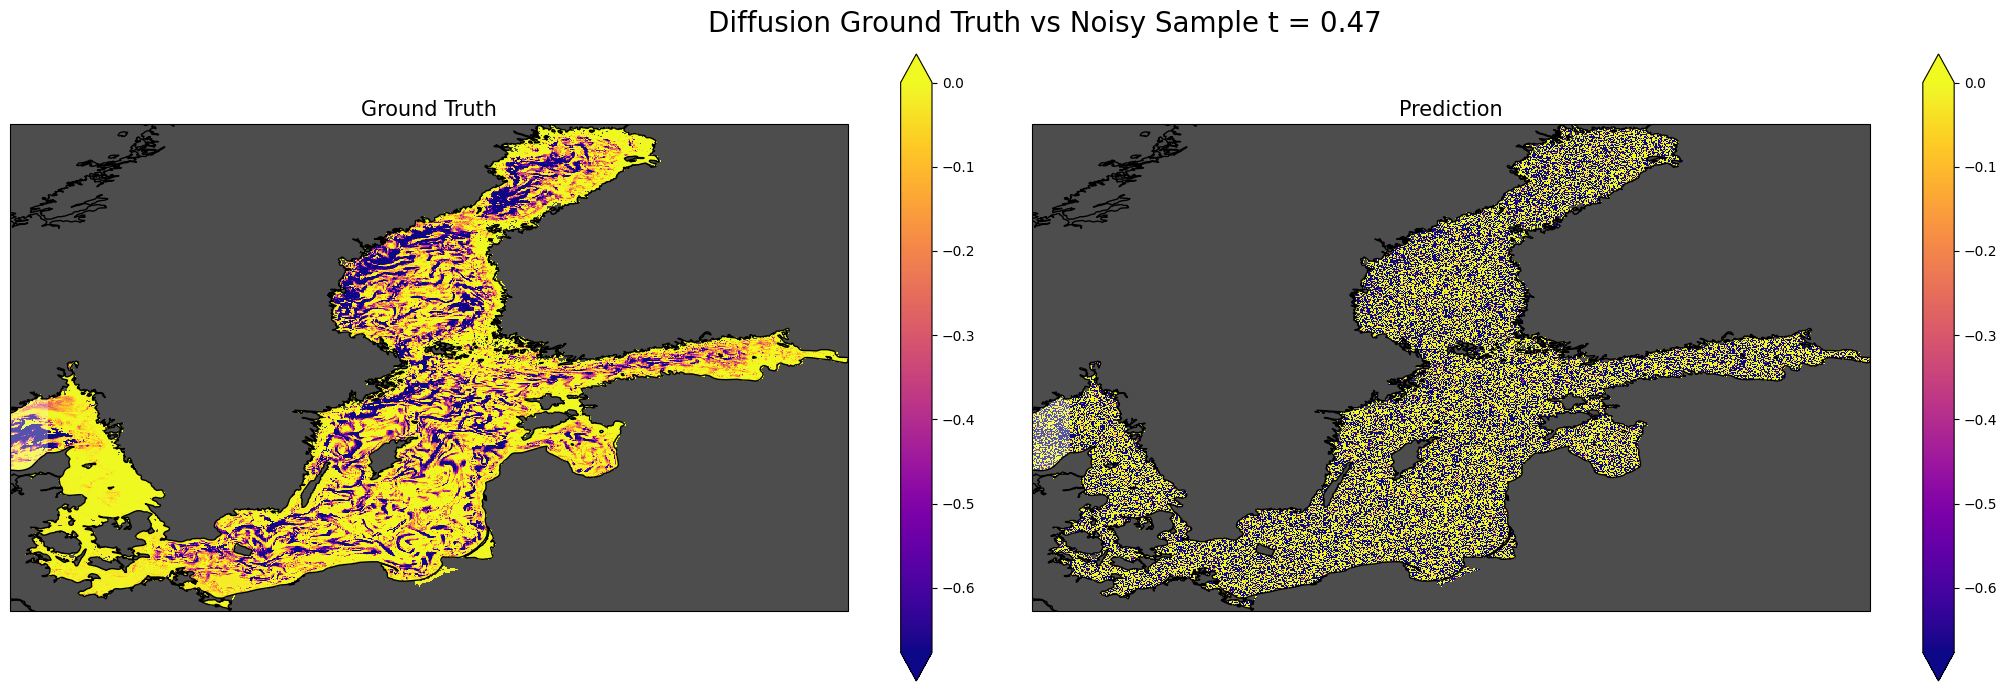

In [7]:
# Diffusion
sigma_max = 88
sigma_min = 0.002
rho = 7
pred_residual = False
n_steps = 10

rnd_uniform = torch.rand([target.shape[0], 1, 1], device=target.device)
print(f"T: {rnd_uniform}")
rho_inv = 1 / rho
sigma_max_rho = sigma_max**rho_inv
sigma_min_rho = sigma_min**rho_inv
sigma = (
    sigma_max_rho + rnd_uniform * (sigma_min_rho - sigma_max_rho)
) ** rho

y = target

print(f"Sigma: {sigma.squeeze().item():.4f}")
n = torch.randn_like(y) * sigma
noisy_input = y + n

da_noisy = create_dataarray_from_tensor(
    tensor=noisy_input,
    time=time_slice,
    split=split,
    category="state",
).unstack("grid_index")

feature_idx = 0  # Choose which weather variable to plot (e.g., temperature)
time_idx = 0     # Choose which time step to plot

# Select a single time and feature from the DataArray
da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)

fig = plot_prediction(
    datastore=datastore,
    da_prediction=da_noisy_selected,
    da_target=da_target_selected,
    vrange=vrange,
    title=f"Diffusion Ground Truth vs Noisy Sample t = {rnd_uniform.squeeze().item():.2f}",
)

In [8]:
import os
import matplotlib.pyplot as plt
import imageio

num_steps = 20
sigma_max = 88
sigma_min = 0.002
time_idx = 0     # Choose which time step to plot

# Time step discretization.
step_indices = torch.arange(num_steps)
t_steps = (
    sigma_max ** (1 / rho)
    + step_indices
    / (num_steps - 1)
    * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))
) ** rho
diff_t_steps = torch.cat(
    [
        torch.as_tensor(t_steps),
        torch.zeros_like(t_steps[:1]),
    ]
)  # t_N = 0

diffusion_steps = []

# Create output directory for frames
frames_dir = "./output/diffusion_frames/mlotst"
os.makedirs(frames_dir, exist_ok=True)
output_path = "./output/diffusion_frames/mlotst.mp4"

frame_files = []
weights=[]

# Loop through sigma values and create frames
for i, sigma in enumerate(diff_t_steps):
    n = torch.randn_like(y) * sigma
    noisy_input = y + n
    diffusion_steps.append(noisy_input)
    weight = (
        (sigma**2 + args.sigma_data**2) / (sigma * args.sigma_data) ** 2
    ).squeeze() 
    weights.append(weight)
    print(f"Processing frame {i+1}/{len(diff_t_steps)}: Sigma = {sigma.item():.4f}, Weight = {weight.item():.4f}")

    da_noisy = create_dataarray_from_tensor(
        tensor=noisy_input,
        time=time_slice,
        split=split,
        category="state"
    ).unstack("grid_index")
    
    da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
    
    fig = plot_prediction(
        datastore=datastore,
        da_prediction=da_noisy_selected,
        da_target=da_target_selected,
        vrange=vrange,
        title=f"Diffusion Process - σ = {sigma.item():.4f}"
    )
    
    # Save this frame
    frame_path = os.path.join(frames_dir, f"frame_{i:03d}.png")
    fig.savefig(frame_path)
    plt.close(fig)
    frame_files.append(frame_path)

# Compile frames into video
print("Creating video...")
with imageio.get_writer(output_path, fps=4) as writer:
    for frame_path in frame_files:
        writer.append_data(imageio.imread(frame_path))

print(f"Video saved to {output_path}")

Processing frame 1/21: Sigma = 88.0000, Weight = 1.0001
Processing frame 2/21: Sigma = 65.5483, Weight = 1.0002
Processing frame 3/21: Sigma = 48.1970, Weight = 1.0004
Processing frame 4/21: Sigma = 34.9415, Weight = 1.0008
Processing frame 5/21: Sigma = 24.9422, Weight = 1.0016
Processing frame 6/21: Sigma = 17.5033, Weight = 1.0033
Processing frame 7/21: Sigma = 12.0533, Weight = 1.0069
Processing frame 8/21: Sigma = 8.1277, Weight = 1.0151
Processing frame 9/21: Sigma = 5.3533, Weight = 1.0349
Processing frame 10/21: Sigma = 3.4337, Weight = 1.0848
Processing frame 11/21: Sigma = 2.1372, Weight = 1.2189
Processing frame 12/21: Sigma = 1.2851, Weight = 1.6055
Processing frame 13/21: Sigma = 0.7426, Weight = 2.8136
Processing frame 14/21: Sigma = 0.4095, Weight = 6.9633
Processing frame 15/21: Sigma = 0.2137, Weight = 22.9032
Processing frame 16/21: Sigma = 0.1043, Weight = 92.9325
Processing frame 17/21: Sigma = 0.0469, Weight = 455.5898
Processing frame 18/21: Sigma = 0.0190, Weight

/tmp/ipykernel_2369/3406450384.py:73: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))
[rawvideo @ 0x564924d3a500] Stream #0: not enough frames to estimate rate; consider increasing probesize


Video saved to ./output/diffusion_frames/mlotst.mp4


In [ ]:
print(diff_t_steps)
sigma_data = 1.0
sigma = diff_t_steps
# Weights for different diffusion-steps
print(((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2))

tensor([8.8000e+01, 6.5548e+01, 4.8197e+01, 3.4942e+01, 2.4942e+01, 1.7503e+01,
        1.2053e+01, 8.1277e+00, 5.3533e+00, 3.4337e+00, 2.1372e+00, 1.2851e+00,
        7.4256e-01, 4.0950e-01, 2.1367e-01, 1.0430e-01, 4.6902e-02, 1.9025e-02,
        6.7508e-03, 2.0000e-03, 0.0000e+00])
tensor([1.0001e+00, 1.0002e+00, 1.0004e+00, 1.0008e+00, 1.0016e+00, 1.0033e+00,
        1.0069e+00, 1.0151e+00, 1.0349e+00, 1.0848e+00, 1.2189e+00, 1.6055e+00,
        2.8136e+00, 6.9633e+00, 2.2903e+01, 9.2932e+01, 4.5559e+02, 2.7639e+03,
        2.1943e+04, 2.5000e+05,        inf])


In [10]:
# Flow Matching
tmin = 0.0
tmax = 1.0

# Create output directory for frames
frames_dir = "./output/flow_matching/mlotst"
os.makedirs(frames_dir, exist_ok=True)
output_path = "./output/flow_matching/mlotst.mp4"
frame_files = []
fm_steps = []

# Time step discretization.
t_steps = torch.linspace(tmin, tmax, num_steps)

for i, t in enumerate(t_steps):
    z0 = torch.randn_like(target)
    z1 = target
    zt = (1 - t) * z0 + t * z1
    fm_steps.append(zt)

    da_noisy = create_dataarray_from_tensor(
        tensor=zt,
        time=time_slice,
        split=split,
        category="state"
    ).unstack("grid_index")
    
    da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
    
    fig = plot_prediction(
        datastore=datastore,
        da_prediction=da_noisy_selected,
        da_target=da_target_selected,
        vrange=vrange,
        title=f"t = {t:.4f}"
    )
    
    # Save this frame
    frame_path = os.path.join(frames_dir, f"frame_{i:03d}.png")
    fig.savefig(frame_path)
    plt.close(fig)
    frame_files.append(frame_path)

# Compile frames into video
print("Creating video...")
with imageio.get_writer(output_path, fps=4) as writer:
    for frame_path in frame_files:
        writer.append_data(imageio.imread(frame_path))

print(f"Video saved to {output_path}")
    


Creating video...


/tmp/ipykernel_2369/734260650.py:48: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))
[rawvideo @ 0x55a3e66c8500] Stream #0: not enough frames to estimate rate; consider increasing probesize


Video saved to ./output/flow_matching/mlotst.mp4


In [11]:
import gc

# Clear PyTorch's CUDA cache
torch.cuda.empty_cache()

# Force garbage collection
gc.collect()

# Print memory usage to monitor
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU memory allocated: 0.10 GB
GPU memory reserved: 0.11 GB


In [ ]:
import os

torch.cuda.empty_cache() # Clear GPU memory
if args.model == "EDM":
    # Create output directory for frames
    frames_dir = "./output/diffusion_model_steps/mlotst"
    os.makedirs(frames_dir, exist_ok=True)
    video_path = "./output/diffusion_model_steps/mlotst.mp4"
    frame_files = []
    model_steps = []

    def heun_sampler(
            model,
            latents,
            class_labels=None,
            boundary_forcing=None,
            randn_like=torch.randn_like,
            num_steps=20,
            sigma_min=0.03,
            sigma_max=80,
            rho=7,
        ):
            with torch.no_grad():
                # Adjust noise levels based on what's supported by the network.
                sigma_min = max(sigma_min, model.sigma_min)
                sigma_max = min(sigma_max, model.sigma_max)

                # Time step discretization.
                step_indices = torch.arange(num_steps)
                t_steps = (
                    sigma_max ** (1 / rho)
                    + step_indices
                    / (num_steps - 1)
                    * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))
                ) ** rho
                t_steps = torch.cat(
                    [
                        torch.as_tensor(t_steps, device=latents.device),
                        torch.zeros_like(t_steps[:1], device=latents.device),
                    ]
                )  # t_N = 0

                # Main sampling loop.
                x_next = latents * t_steps[0]

                da_noisy = create_dataarray_from_tensor(
                    tensor=x_next.detach(),
                    time=time_slice,
                    split=split,
                    category="state"
                ).unstack("grid_index")
                
                da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
                
                fig = plot_prediction(
                    datastore=datastore,
                    da_prediction=da_noisy_selected,
                    da_target=da_target_selected,
                    vrange=vrange,
                    title=f"sigma = {sigma_max:.4f}"
                )

                frame_path = os.path.join(frames_dir, f"frame_{0:03d}.png")
                fig.savefig(frame_path, dpi=100, bbox_inches='tight')
                plt.close(fig)
                frame_files.append(frame_path)

                model_steps.append(x_next)
                torch.cuda.empty_cache()  # Add this after each append

                for i, (t_cur, t_next) in enumerate(
                    zip(t_steps[:-1], t_steps[1:])
                ):  # 0, ..., N-1
                    x_cur = x_next
                    print(f"Step {i+1}/{num_steps}: t_cur={t_cur:.4f}, t_next={t_next:.4f}")

                    denoised = model.denoise(x_cur, t_cur, class_labels=class_labels)
                    d_cur = (x_cur - denoised) / t_cur
                    x_next = x_cur + (t_next - t_cur) * d_cur

                    # Apply 2nd order correction.
                    if i < num_steps - 1:
                        denoised = model.denoise(
                            x_next, t_next, class_labels=class_labels
                        )
                        d_prime = (x_next - denoised) / t_next
                        x_next = x_cur + (t_next - t_cur) * (
                            0.5 * d_cur + 0.5 * d_prime
                        )

                    da_noisy = create_dataarray_from_tensor(
                        tensor=x_next.detach(),
                        time=time_slice,
                        split=split,
                        category="state"
                    ).unstack("grid_index")
                    
                    da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
                    
                    fig = plot_prediction(
                        datastore=datastore,
                        da_prediction=da_noisy_selected,
                        da_target=da_target_selected,
                        vrange=vrange,
                        title=f"sigma = {t_cur:.4f}"
                    )

                    frame_path = os.path.join(frames_dir, f"frame_{i+1:03d}.png")
                    fig.savefig(frame_path, dpi=100, bbox_inches='tight')
                    plt.close(fig)
                    frame_files.append(frame_path)

                    model_steps.append(x_next)
                    torch.cuda.empty_cache()  # Add this after each append

                # Read first image to get dimensions
                first_img = imageio.imread(frame_files[0])
                height, width, _ = first_img.shape

                # Create video from the frames with consistent size
                print("Creating distribution comparison video...")
                with imageio.get_writer(video_path, fps=2) as writer:
                    for frame_path in frame_files:
                        # Read frame and resize to match first frame if needed
                        img = imageio.imread(frame_path)
                        if img.shape[0] != height or img.shape[1] != width:
                            from PIL import Image
                            img = np.array(Image.fromarray(img).resize((width, height)))
                        writer.append_data(img)

                print(f"Video saved to {video_path}")

                return x_next

    latents = torch.randn_like(target).to(device)
    input_grid = torch.cat(
        (prev_state, prev_prev_state, forcing), dim=-1
    ).to(device)  # (B, N_grid, d_input)
    
    with torch.no_grad():
        pred = heun_sampler(
            model=model,
            latents=latents,
            num_steps=100,
            sigma_min=0.002,
            sigma_max=88,
            rho=7,
            class_labels=input_grid
        )



In [21]:
if args.model == "FM":
    # Create output directory for frames
    frames_dir = "./output/FM_model_steps/mlotst"
    os.makedirs(frames_dir, exist_ok=True)
    video_path = "./output/FM_model_steps/mlotst.mp4"
    frame_files = []
    model_steps = []

    def heun_sampler(
        model, latents, class_labels=None, boundary_forcing=None, randn_like=torch.randn_like,
        num_steps=20,
    ):
        tmin = 0.0
        tmax = 1.0

        # Time step discretization.
        t_steps = torch.linspace(tmin, tmax, num_steps, device=device)

        # Main sampling loop.
        x_next = latents

        da_noisy = create_dataarray_from_tensor(
            tensor=x_next.detach(),
            time=time_slice,
            split=split,
            category="state"
        ).unstack("grid_index")
        
        da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
        
        fig = plot_prediction(
            datastore=datastore,
            da_prediction=da_noisy_selected,
            da_target=da_target_selected,
            vrange=vrange,
            title=f"t = {tmin:.4f}"
        )

        frame_path = os.path.join(frames_dir, f"frame_{0:03d}.png")
        fig.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        frame_files.append(frame_path)

        model_steps.append(x_next)
        torch.cuda.empty_cache()  # Add this after each append

        # 0, ..., N-1
        for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
            t_cur = t_cur.reshape(-1, 1, 1).flatten()
            t_next = t_next.reshape(-1, 1, 1).flatten()
            print(f"Step {i+1}/{num_steps}: t_cur={t_cur.item():.4f}, t_next={t_next.item():.4f}")

            # Euler step.
            x_cur = x_next
            d_cur = model(x_cur, t_cur, class_labels)
            x_next = x_cur + (t_next - t_cur) * d_cur

            # Apply 2nd order correction.
            if i < num_steps - 1:
                d_prime = model(
                    x_next, t_next, class_labels)
                x_next = x_cur + (t_next - t_cur) * \
                    (0.5 * d_cur + 0.5 * d_prime)

            da_noisy = create_dataarray_from_tensor(
                tensor=x_next.detach(),
                time=time_slice,
                split=split,
                category="state"
            ).unstack("grid_index")
            
            da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
            
            fig = plot_prediction(
                datastore=datastore,
                da_prediction=da_noisy_selected,
                da_target=da_target_selected,
                vrange=vrange,
                title=f"t = {t_cur.item():.4f}"
            )

            frame_path = os.path.join(frames_dir, f"frame_{i+1:03d}.png")
            fig.savefig(frame_path, dpi=100, bbox_inches='tight')
            plt.close(fig)
            frame_files.append(frame_path)

            model_steps.append(x_next)
            torch.cuda.empty_cache()  # Add this after each append
            
        # Read first image to get dimensions
        first_img = imageio.imread(frame_files[0])
        height, width, _ = first_img.shape

        # Create video from the frames with consistent size
        print("Creating distribution comparison video...")
        with imageio.get_writer(video_path, fps=2) as writer:
            for frame_path in frame_files:
                # Read frame and resize to match first frame if needed
                img = imageio.imread(frame_path)
                if img.shape[0] != height or img.shape[1] != width:
                    from PIL import Image
                    img = np.array(Image.fromarray(img).resize((width, height)))
                writer.append_data(img)

        print(f"Video saved to {video_path}")

        return x_next

    def stochastic_sampler(
        model, latents, class_labels=None, boundary_forcing=None, randn_like=torch.randn_like,
            num_steps=20, sigma_min=0.03, sigma_max=80, rho=7,
    ):
        tmin = 0.0
        tmax = 1
        eps = 1.0

        # Time step discretization.
        ts = torch.linspace(tmin, tmax, num_steps+1, device=device)[:-1]
        dt = (tmax - tmin) / num_steps

        # Main sampling loop.
        zt = latents  # Initialize with noise
        da_noisy = create_dataarray_from_tensor(
            tensor=zt.detach(),
            time=time_slice,
            split=split,
            category="state"
        ).unstack("grid_index")
        
        da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
        
        fig = plot_prediction(
            datastore=datastore,
            da_prediction=da_noisy_selected,
            da_target=da_target_selected,
            vrange=vrange,
            title=f"t = {tmin:.4f}"
        )

        frame_path = os.path.join(frames_dir, f"frame_{0:03d}.png")
        fig.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        frame_files.append(frame_path)

        model_steps.append(zt)
        torch.cuda.empty_cache()  # Add this after each append

        for t in ts:
            alpha_t = t
            beta_t = 1 - t
            gamma_t = 1
            alpha_dot_t = 1
            beta_dot_t = -1
            eps_t = eps * beta_t
            print(f"t={t:.4f}")

            t_reshaped = t.reshape(1)  # Add batch dimension
            b = model(zt, t_reshaped, class_labels)
            s = (alpha_t * b - alpha_dot_t * zt) / (beta_t * gamma_t) # s = (t * b - zt) / (1 - t)
            dz = b + eps_t * s

            dW = torch.randn_like(zt) * torch.sqrt(2*dt * eps_t)

            zt = zt + dz * dt + dW
            da_noisy = create_dataarray_from_tensor(
                tensor=zt.detach(),
                time=time_slice,
                split=split,
                category="state"
            ).unstack("grid_index")
            
            da_noisy_selected = da_noisy.isel(time=time_idx, state_feature=feature_idx)
            
            fig = plot_prediction(
                datastore=datastore,
                da_prediction=da_noisy_selected,
                da_target=da_target_selected,
                vrange=vrange,
                title=f"t = {t:.4f}"
            )

            frame_path = os.path.join(frames_dir, f"frame_{i+1:03d}.png")
            fig.savefig(frame_path, dpi=100, bbox_inches='tight')
            plt.close(fig)
            frame_files.append(frame_path)

            model_steps.append(zt)
            torch.cuda.empty_cache()  # Add this after each append
            
        # Read first image to get dimensions
        first_img = imageio.imread(frame_files[0])
        height, width, _ = first_img.shape

        # Create video from the frames with consistent size
        print("Creating distribution comparison video...")
        with imageio.get_writer(video_path, fps=2) as writer:
            for frame_path in frame_files:
                # Read frame and resize to match first frame if needed
                img = imageio.imread(frame_path)
                if img.shape[0] != height or img.shape[1] != width:
                    from PIL import Image
                    img = np.array(Image.fromarray(img).resize((width, height)))
                writer.append_data(img)

        print(f"Video saved to {video_path}")

        return zt  # (B, N_grid, d_state)
    
    latents = torch.randn_like(target).to(device)
    input_grid = torch.cat(
        (prev_state, prev_prev_state, forcing), dim=-1
    ).to(device)  # (B, N_grid, d_input)
    with torch.no_grad():
        pred = stochastic_sampler(
            model=model.model,
            latents=latents,
            num_steps=100,
            class_labels=input_grid
        )

t=0.0000
t=0.0100
t=0.0200
t=0.0300
t=0.0400
t=0.0500
t=0.0600
t=0.0700
t=0.0800
t=0.0900
t=0.1000
t=0.1100
t=0.1200
t=0.1300
t=0.1400
t=0.1500
t=0.1600
t=0.1700
t=0.1800
t=0.1900
t=0.2000
t=0.2100
t=0.2200
t=0.2300
t=0.2400
t=0.2500
t=0.2600
t=0.2700
t=0.2800
t=0.2900
t=0.3000
t=0.3100
t=0.3200
t=0.3300
t=0.3400
t=0.3500
t=0.3600
t=0.3700
t=0.3800
t=0.3900
t=0.4000
t=0.4100
t=0.4200
t=0.4300
t=0.4400
t=0.4500
t=0.4600
t=0.4700
t=0.4800
t=0.4900
t=0.5000
t=0.5100
t=0.5200
t=0.5300
t=0.5400
t=0.5500
t=0.5600
t=0.5700
t=0.5800
t=0.5900
t=0.6000
t=0.6100
t=0.6200
t=0.6300
t=0.6400
t=0.6500
t=0.6600
t=0.6700
t=0.6800
t=0.6900
t=0.7000
t=0.7100
t=0.7200
t=0.7300
t=0.7400
t=0.7500
t=0.7600
t=0.7700
t=0.7800
t=0.7900
t=0.8000
t=0.8100
t=0.8200
t=0.8300
t=0.8400
t=0.8500
t=0.8600
t=0.8700
t=0.8800
t=0.8900
t=0.9000
t=0.9100
t=0.9200
t=0.9300
t=0.9400
t=0.9500
t=0.9600
t=0.9700
t=0.9800
t=0.9900


/tmp/ipykernel_2369/2130685855.py:191: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  first_img = imageio.imread(frame_files[0])
/tmp/ipykernel_2369/2130685855.py:199: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(frame_path)


Creating distribution comparison video...


[rawvideo @ 0x559156bb3500] Stream #0: not enough frames to estimate rate; consider increasing probesize


Video saved to ./output/FM_model_steps/mlotst.mp4


In [14]:
import os
import matplotlib.pyplot as plt
import numpy as np
import imageio
from scipy import stats
from PIL import Image

# Create output directories for frames and video
dist_frames_dir = "./output/four_way_distribution_comparison/frames"
os.makedirs(dist_frames_dir, exist_ok=True)
video_path = "./output/four_way_distribution_comparison/comparison.mp4"
os.makedirs(os.path.dirname(video_path), exist_ok=True)

frame_files = []

# Extract ground truth data (will be the same for all steps)
ground_truth = target[0,:,feature_idx].cpu().numpy()

# Ensure all lists have the same length for comparison
steps_to_compare = min(len(fm_steps), len(diffusion_steps), len(model_steps))

# Loop through all steps
for step in range(steps_to_compare):
    print(f"Processing step {step+1}/{steps_to_compare}")
    
    # Extract the data
    fm_sample = fm_steps[step][0,:,feature_idx].cpu().numpy()
    diff_sample = diffusion_steps[step][0,:,feature_idx].cpu().numpy()
    model_diff_sample = model_steps[step][0,:,feature_idx].cpu().numpy()

    # Create figure for comparison - SET FIXED FIGURE SIZE
    fig, ax = plt.subplots(2, 2, figsize=(20, 12))
    
    # Color scheme for consistency
    gt_color = 'black'
    fm_color = 'blue'
    diff_color = 'red'
    model_diff_color = 'green'

    # Plot histograms (all distributions overlaid)
    ax[0,0].hist(ground_truth, bins=50, alpha=0.4, color=gt_color, label='Ground Truth')
    ax[0,0].hist(fm_sample, bins=50, alpha=0.4, color=fm_color, label='Flow Matching')
    ax[0,0].hist(diff_sample, bins=50, alpha=0.4, color=diff_color, label='Diffusion')
    ax[0,0].hist(model_diff_sample, bins=50, alpha=0.4, color=model_diff_color, label='Model Diffusion')
    ax[0,0].set_title('Overlay Histogram Comparison')
    ax[0,0].set_xlabel('Pixel Value')
    ax[0,0].set_ylabel('Count')
    ax[0,0].legend()

    # Plot kernel density estimates
    gt_kde = stats.gaussian_kde(ground_truth)
    fm_kde = stats.gaussian_kde(fm_sample)
    diff_kde = stats.gaussian_kde(diff_sample)
    model_diff_kde = stats.gaussian_kde(model_diff_sample)
    
    # Find common x-range for all distributions
    min_val = min(ground_truth.min(), fm_sample.min(), diff_sample.min(), model_diff_sample.min())
    max_val = max(ground_truth.max(), fm_sample.max(), diff_sample.max(), model_diff_sample.max())
    x_range = np.linspace(min_val, max_val, 1000)

    # Plot density curves
    ax[0,1].plot(x_range, gt_kde(x_range), color=gt_color, label='Ground Truth')
    ax[0,1].plot(x_range, fm_kde(x_range), color=fm_color, label='Flow Matching')
    ax[0,1].plot(x_range, diff_kde(x_range), color=diff_color, label='Diffusion')
    ax[0,1].plot(x_range, model_diff_kde(x_range), color=model_diff_color, label='Model Diffusion')
    ax[0,1].set_title('Kernel Density Estimate Comparison')
    ax[0,1].set_xlabel('Pixel Value')
    ax[0,1].set_ylabel('Density')
    ax[0,1].legend()
    
    # Add box plots for quick visual comparison
    box_data = [ground_truth, fm_sample, diff_sample, model_diff_sample]
    ax[1,0].boxplot(box_data, labels=['Ground Truth', 'Flow Matching', 'Diffusion', 'Model Diffusion'])
    ax[1,0].set_title('Box Plot Comparison')
    ax[1,0].set_ylabel('Pixel Value')
    
    # Add text panel with statistics
    ax[1,1].axis('off')  # No axes for the text panel
    
    # Calculate statistics for all distributions
    gt_stats = {
        'Mean': np.mean(ground_truth),
        'Std Dev': np.std(ground_truth),
        'Min': np.min(ground_truth),
        'Max': np.max(ground_truth),
        'Median': np.median(ground_truth)
    }
    
    fm_stats = {
        'Mean': np.mean(fm_sample),
        'Std Dev': np.std(fm_sample),
        'Min': np.min(fm_sample),
        'Max': np.max(fm_sample),
        'Median': np.median(fm_sample)
    }

    diff_stats = {
        'Mean': np.mean(diff_sample),
        'Std Dev': np.std(diff_sample),
        'Min': np.min(diff_sample),
        'Max': np.max(diff_sample),
        'Median': np.median(diff_sample)
    }
    
    model_diff_stats = {
        'Mean': np.mean(model_diff_sample),
        'Std Dev': np.std(model_diff_sample),
        'Min': np.min(model_diff_sample),
        'Max': np.max(model_diff_sample),
        'Median': np.median(model_diff_sample)
    }
    
    # Calculate statistical tests between ground truth and each method
    ks_gt_fm = stats.ks_2samp(ground_truth, fm_sample)
    ks_gt_diff = stats.ks_2samp(ground_truth, diff_sample)
    ks_gt_model = stats.ks_2samp(ground_truth, model_diff_sample)
    
    # Create statistics text
    stats_text = f"Step {step}/{steps_to_compare-1}\n"
    stats_text += f"t_flow = {t_steps[step]:.4f}, σ_diff = {diff_t_steps[step]:.4f}\n\n"
    
    stats_text += "Ground Truth Statistics:\n"
    for stat, value in gt_stats.items():
        stats_text += f"  {stat}: {value:.4f}\n"
    
    stats_text += "\nFlow Matching Statistics:\n"
    for stat, value in fm_stats.items():
        stats_text += f"  {stat}: {value:.4f}\n"
    
    stats_text += "\nDiffusion Statistics:\n"
    for stat, value in diff_stats.items():
        stats_text += f"  {stat}: {value:.4f}\n"
    
    stats_text += "\nModel Statistics:\n"
    for stat, value in model_diff_stats.items():
        stats_text += f"  {stat}: {value:.4f}\n"
    
    stats_text += "\nKS Tests vs Ground Truth:\n"
    stats_text += f"  GT vs FM: stat={ks_gt_fm[0]:.4f}, p={ks_gt_fm[1]:.4e}\n"
    stats_text += f"  GT vs Diff: stat={ks_gt_diff[0]:.4f}, p={ks_gt_diff[1]:.4e}\n"
    stats_text += f"  GT vs Model: stat={ks_gt_model[0]:.4f}, p={ks_gt_model[1]:.4e}\n"
    
    # Add the text to the figure
    ax[1,1].text(0.0, 0.5, stats_text, fontsize=9, va='center', family='monospace')
    
    # Add overall title
    fig.suptitle(f"Distribution Comparison - Step {step}/{steps_to_compare-1}", fontsize=16)
    
    # Use tight_layout with fixed parameters
    plt.tight_layout(pad=2.0)
    
    # Save this frame - USE FIXED DPI and PAD INCHES to ensure consistent size
    frame_path = os.path.join(dist_frames_dir, f"frame_{step:03d}.png")
    fig.savefig(frame_path, dpi=100, bbox_inches=None)
    plt.close(fig)
    frame_files.append(frame_path)
    
    # Print statistics to console as well
    print(stats_text)
    print("-" * 50)

# Create video from the frames with consistent size
print("Creating distribution comparison video...")

# Two approaches to handle this:

# OPTION 1: Read all images first and resize to the same dimensions
print("Reading images and standardizing dimensions...")
frames = []
for frame_path in frame_files:
    img = Image.open(frame_path)
    frames.append(np.array(img))

# Get the modal height and width (most common dimensions)
heights = [frame.shape[0] for frame in frames]
widths = [frame.shape[1] for frame in frames]
from collections import Counter
height = Counter(heights).most_common(1)[0][0]  
width = Counter(widths).most_common(1)[0][0]

# Resize all frames to the modal dimensions
print(f"Standardizing all frames to {width}x{height}")
standardized_frames = []
for frame in frames:
    if frame.shape[0] != height or frame.shape[1] != width:
        resized_img = np.array(Image.fromarray(frame).resize((width, height)))
        standardized_frames.append(resized_img)
    else:
        standardized_frames.append(frame)

# Create video
with imageio.get_writer(video_path, fps=2) as writer:
    for frame in standardized_frames:
        writer.append_data(frame)

print(f"Video saved to {video_path}")

Processing step 1/20


/tmp/ipykernel_2369/3141295486.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,0].boxplot(box_data, labels=['Ground Truth', 'Flow Matching', 'Diffusion', 'Model Diffusion'])


Step 0/19
t_flow = 0.0000, σ_diff = 88.0000

Ground Truth Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6505
  Max: 4.8358
  Median: -0.0196

Flow Matching Statistics:
  Mean: 0.0001
  Std Dev: 0.9974
  Min: -4.5267
  Max: 4.4295
  Median: -0.0000

Diffusion Statistics:
  Mean: -0.2850
  Std Dev: 88.2640
  Min: -372.0925
  Max: 419.3889
  Median: -0.4006

Model Statistics:
  Mean: 0.0007
  Std Dev: 0.9998
  Min: -4.5932
  Max: 4.4801
  Median: 0.0011

KS Tests vs Ground Truth:
  GT vs FM: stat=0.3215, p=0.0000e+00
  GT vs Diff: stat=0.4905, p=0.0000e+00
  GT vs Model: stat=0.3231, p=0.0000e+00

--------------------------------------------------
Processing step 2/20


/tmp/ipykernel_2369/3141295486.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,0].boxplot(box_data, labels=['Ground Truth', 'Flow Matching', 'Diffusion', 'Model Diffusion'])


Step 1/19
t_flow = 0.0526, σ_diff = 65.5483

Ground Truth Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6505
  Max: 4.8358
  Median: -0.0196

Flow Matching Statistics:
  Mean: -0.0079
  Std Dev: 0.9466
  Min: -3.9891
  Max: 3.9885
  Median: -0.0067

Diffusion Statistics:
  Mean: -0.4496
  Std Dev: 65.7234
  Min: -273.6028
  Max: 293.7230
  Median: -0.5011

Model Statistics:
  Mean: -0.0036
  Std Dev: 0.9998
  Min: -4.5982
  Max: 4.4751
  Median: -0.0032

KS Tests vs Ground Truth:
  GT vs FM: stat=0.3153, p=0.0000e+00
  GT vs Diff: stat=0.4877, p=0.0000e+00
  GT vs Model: stat=0.3215, p=0.0000e+00

--------------------------------------------------
Processing step 3/20


...

Step 18/19
t_flow = 0.9474, σ_diff = 0.0068

Ground Truth Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6505
  Max: 4.8358
  Median: -0.0196

Flow Matching Statistics:
  Mean: -0.1544
  Std Dev: 0.4476
  Min: -10.1155
  Max: 4.6371
  Median: -0.0448

Diffusion Statistics:
  Mean: -0.1628
  Std Dev: 0.4695
  Min: -10.6557
  Max: 4.8378
  Median: -0.0204

Model Statistics:
  Mean: -0.0798
  Std Dev: 0.9991
  Min: -4.6897
  Max: 4.3893
  Median: -0.0793

KS Tests vs Ground Truth:
  GT vs FM: stat=0.0959, p=0.0000e+00
  GT vs Diff: stat=0.0166, p=4.7098e-18
  GT vs Model: stat=0.2927, p=0.0000e+00

--------------------------------------------------
Processing step 20/20


/tmp/ipykernel_2369/3141295486.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,0].boxplot(box_data, labels=['Ground Truth', 'Flow Matching', 'Diffusion', 'Model Diffusion'])


Step 19/19
t_flow = 1.0000, σ_diff = 0.0020

Ground Truth Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6505
  Max: 4.8358
  Median: -0.0196

Flow Matching Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6505
  Max: 4.8358
  Median: -0.0196

Diffusion Statistics:
  Mean: -0.1628
  Std Dev: 0.4694
  Min: -10.6496
  Max: 4.8361
  Median: -0.0194

Model Statistics:
  Mean: -0.0847
  Std Dev: 0.9991
  Min: -4.6954
  Max: 4.3834
  Median: -0.0844

KS Tests vs Ground Truth:
  GT vs FM: stat=0.0000, p=1.0000e+00
  GT vs Diff: stat=0.0047, p=7.4015e-02
  GT vs Model: stat=0.2909, p=0.0000e+00

--------------------------------------------------
Creating distribution comparison video...
Reading images and standardizing dimensions...
Standardizing all frames to 2000x1200


[rawvideo @ 0x55812e8854c0] Stream #0: not enough frames to estimate rate; consider increasing probesize


Video saved to ./output/four_way_distribution_comparison/comparison.mp4


In [15]:
diff_t_steps

tensor([8.8000e+01, 6.5548e+01, 4.8197e+01, 3.4942e+01, 2.4942e+01, 1.7503e+01,
        1.2053e+01, 8.1277e+00, 5.3533e+00, 3.4337e+00, 2.1372e+00, 1.2851e+00,
        7.4256e-01, 4.0950e-01, 2.1367e-01, 1.0430e-01, 4.6902e-02, 1.9025e-02,
        6.7508e-03, 2.0000e-03, 0.0000e+00])

In [16]:
diff_t_steps[1:] - diff_t_steps[:-1]

tensor([-2.2452e+01, -1.7351e+01, -1.3255e+01, -9.9993e+00, -7.4389e+00,
        -5.4500e+00, -3.9256e+00, -2.7744e+00, -1.9196e+00, -1.2965e+00,
        -8.5204e-01, -5.4256e-01, -3.3306e-01, -1.9583e-01, -1.0938e-01,
        -5.7394e-02, -2.7877e-02, -1.2274e-02, -4.7508e-03, -2.0000e-03])